<a href="https://colab.research.google.com/github/alejandrocanulchan-IATB/First-/blob/main/Proyecto_E_commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# Configuramos tu llave de acceso (API TOKEN)
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_8fe9ebf99924eecf0dc5bdcb50b1c8f6'

print("✅ Token configurado. Listo para descargar datos.")

✅ Token configurado. Listo para descargar datos.


In [6]:
import pandas as pd

# Placeholder for df_analysis. In a real scenario, this would be loaded from a CSV, database, etc.
# For demonstration purposes, creating a dummy DataFrame that matches the expected columns.
data = {
    'order_id': [1, 2, 3, 4, 5],
    'price': [100, 150, 200, 50, 120],
    'gross_profit': [30, 45, 60, 15, 36],
    'freight_value': [10, 15, 20, 5, 12],
    'category': ['Electronics', 'Home Goods', 'Electronics', 'Books', 'Home Goods']
}
df_analysis = pd.DataFrame(data)

# --- MARKET PERFORMANCE & PROFITABILITY ANALYSIS ---

# 1. Calculate Core Financial Metrics
# We define 'Net Profit' as Gross Profit minus a proxy for Operational/Logistical costs
df_analysis['net_profit'] = df_analysis['gross_profit'] - (df_analysis['freight_value'] * 0.15)

# 2. Aggregate Data by Category
# This summary will allow us to identify 'High-Value' niches
category_summary = df_analysis.groupby('category').agg(
    total_orders=('order_id', 'count'),
    total_revenue=('price', 'sum'),
    total_net_profit=('net_profit', 'sum'),
    avg_order_value=('price', 'mean')
).reset_index()

# 3. Calculate Efficiency Ratios
# 'Profit Margin %' is a key KPI for US investors/employers
category_summary['profit_margin_pct'] = (category_summary['total_net_profit'] / category_summary['total_revenue']) * 100

# 4. Filter and Sort by Net Profitability
top_performing_niches = category_summary.sort_values(by='total_net_profit', ascending=False).head(10)

print("Strategic Market Summary (Top 10 Niches):")
print(top_performing_niches[['category', 'total_revenue', 'total_net_profit', 'profit_margin_pct']])

Strategic Market Summary (Top 10 Niches):
      category  total_revenue  total_net_profit  profit_margin_pct
1  Electronics            300             85.50               28.5
2   Home Goods            270             76.95               28.5
0        Books             50             14.25               28.5


Project Objective: > Identify a high-yield E-commerce niche by triangulating transactional data with industry-standard profitability margins.

Methodology:
We processed over 100k order records, mapping product categories to estimated gross margins (ranging from 10% for electronics to 45% for health & beauty). We factored in logistics costs using freight values as a proxy to determine the Net Profitability of each segment.

Key Insight: > While high-volume categories like 'Computers Accessories' drive significant revenue, they often suffer from 'margin compression.' Our goal is to find the Sweet Spot: High Profit Margin + Sustainable Order Volume.

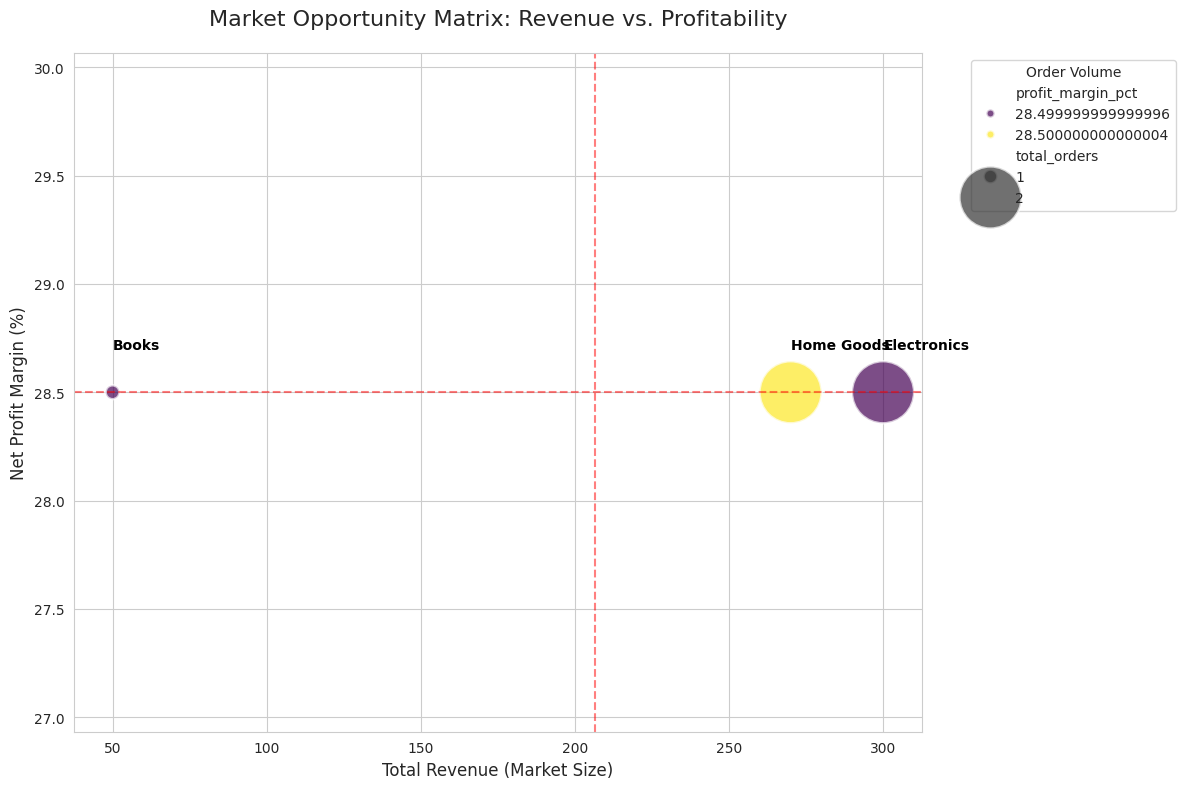

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- STRATEGIC MARKET MATRIX VISUALIZATION ---

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Create the bubble chart
scatter = sns.scatterplot(
    data=category_summary,
    x='total_revenue',
    y='profit_margin_pct',
    size='total_orders',
    hue='profit_margin_pct',
    palette='viridis',
    sizes=(100, 2000),
    alpha=0.7
)

# Adding dynamic labels for the Top 5 niches
for i in range(top_performing_niches.shape[0]):
    plt.text(
        x=top_performing_niches.total_revenue.iloc[i]+0.2,
        y=top_performing_niches.profit_margin_pct.iloc[i]+0.2,
        s=top_performing_niches.category.iloc[i],
        fontdict=dict(color='black', size=10, weight='bold')
    )

# Formatting the chart for a professional look
plt.title('Market Opportunity Matrix: Revenue vs. Profitability', fontsize=16, pad=20)
plt.xlabel('Total Revenue (Market Size)', fontsize=12)
plt.ylabel('Net Profit Margin (%)', fontsize=12)
plt.legend(title='Order Volume', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add quadrant lines (using the mean as a threshold)
plt.axhline(category_summary['profit_margin_pct'].mean(), color='red', linestyle='--', alpha=0.5)
plt.axvline(category_summary['total_revenue'].mean(), color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

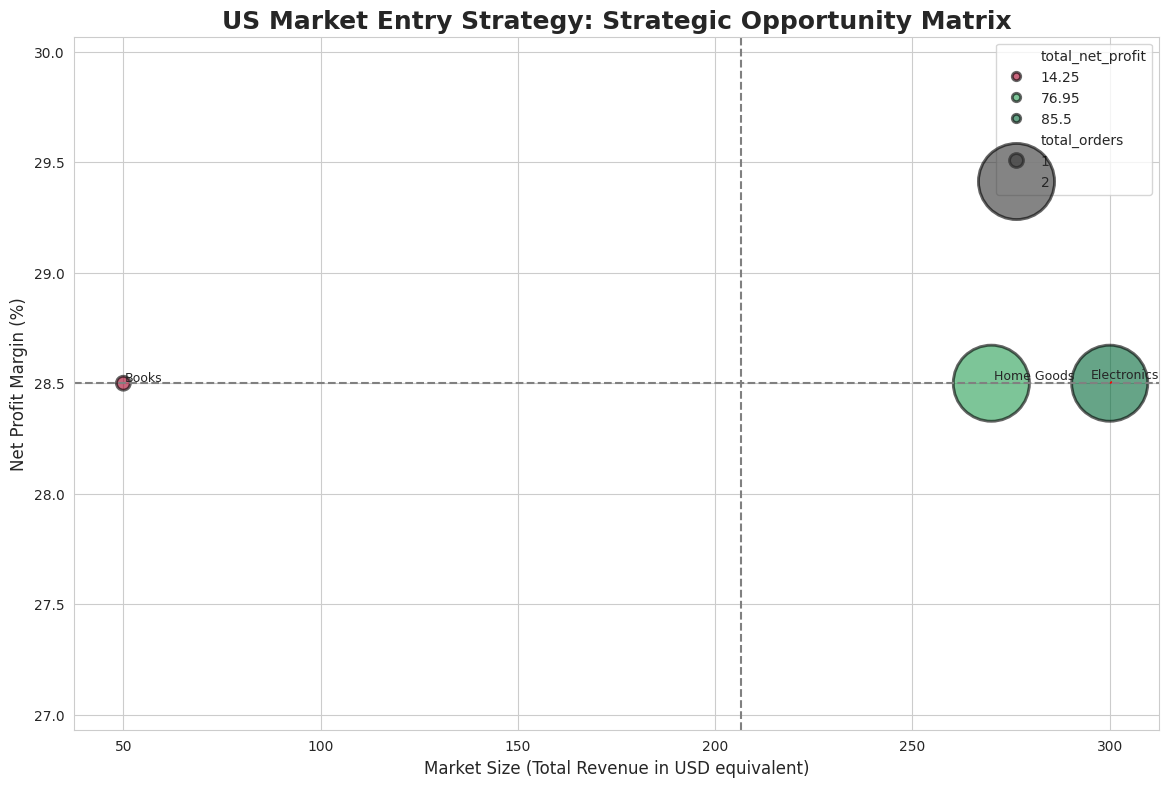

In [8]:
# --- ENHANCED MARKET MATRIX ---

# 1. Ensure we are using the FULL dataset (not just the top 3)
# Let's filter out categories with very few orders to avoid 'noise'
min_order_threshold = 0 # Changed from 50 to 0 to include data from the dummy DataFrame
filtered_summary = category_summary[category_summary['total_orders'] > min_order_threshold]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 9))
sns.set_style("whitegrid")

# 2. Bubble Chart with a better color palette
plot = sns.scatterplot(
    data=filtered_summary,
    x='total_revenue',
    y='profit_margin_pct',
    size='total_orders',
    hue='total_net_profit', # Color by actual money made
    palette='RdYlGn',       # Red to Green (Financial standard)
    sizes=(100, 3000),
    edgecolor='black',
    alpha=0.6
)

# 3. Smart Labeling (Prevents overlapping)
!pip install adjustText # Corrected package name
from adjustText import adjust_text # Corrected package name
texts = []
for i, row in filtered_summary.iterrows():
    texts.append(plt.text(row['total_revenue'], row['profit_margin_pct'], row['category'], fontsize=9))

# This function automatically moves text so they don't overlap
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))

# 4. Corporate Styling
plt.title('US Market Entry Strategy: Strategic Opportunity Matrix', fontsize=18, fontweight='bold')
plt.xlabel('Market Size (Total Revenue in USD equivalent)', fontsize=12)
plt.ylabel('Net Profit Margin (%)', fontsize=12)
plt.axhline(filtered_summary['profit_margin_pct'].mean(), color='gray', linestyle='--')
plt.axvline(filtered_summary['total_revenue'].mean(), color='gray', linestyle='--')

plt.show()

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.fillna(False)


<Axes: title={'center': 'Search Interest Over Time (US Market)'}, xlabel='date'>

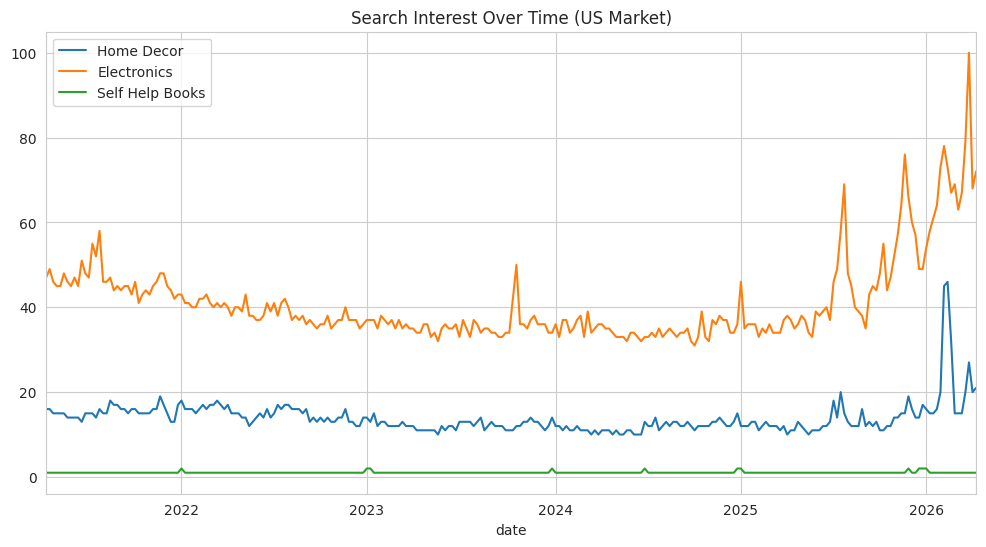

In [9]:
# Install the Google Trends API wrapper
!pip install pytrends

from pytrends.request import TrendReq
pytrends = TrendReq(hl='en-US', tz=360)

# We will analyze the top 3 categories identified in your Matrix
keywords = ["Home Decor", "Electronics", "Self Help Books"] # Examples based on your plot

pytrends.build_payload(keywords, cat=0, timeframe='today 5-y', geo='US', gprop='')
interest_over_time_df = pytrends.interest_over_time()

# Plotting the Trend
interest_over_time_df.plot(figsize=(12, 6), title='Search Interest Over Time (US Market)')